# Afinador Digital de Guitarra con FFT
**Análisis Numérico — Ciclo 01-2026 | Universidad Centroamericana José Simeón Cañas (UCA)**

Este notebook implementa y valida un algoritmo de afinación digital para guitarra acústica basado en el análisis espectral mediante la Transformada Rápida de Fourier (FFT). El trabajo está organizado en las siguientes secciones:

1. Muestreo digital y parámetros del sistema
2. Implementación de funciones de procesamiento (DFT, FFT, ventaneo, HPS)
3. Comparación DFT manual vs FFT — análisis de complejidad computacional
4. Efecto del ventaneo de Hanning sobre el *spectral leakage*
5. Análisis de audios grabados (cuerdas reales)
6. Validación con señales sintéticas
7. Trade-off: resolución espectral, latencia y costo computacional

## 1. Muestreo digital y parámetros del sistema

Una señal acústica continua $x(t)$ generada por la vibración de una cuerda de guitarra debe ser discretizada para su procesamiento computacional. Este proceso, denominado **muestreo**, consiste en tomar muestras de la señal a intervalos regulares $\Delta t = 1/f_s$, produciendo una secuencia discreta:

$$x[n] = x(n \cdot \Delta t), \quad n = 0, 1, \dots, N-1 \tag{1}$$

Para garantizar que no ocurra solapamiento (*aliasing*) en la representación digital, el **Teorema de Muestreo de Nyquist-Shannon** establece que la tasa de muestreo debe satisfacer:

$$f_s > 2 \cdot f_{\max} \tag{2}$$

donde $f_{\max}$ es la frecuencia más alta presente en la señal. Las cuerdas de guitarra producen fundamentales entre $82.41$ Hz y $329.63$ Hz, pero sus armónicos superiores pueden alcanzar varios kHz, justificando el uso del estándar de audio comercial $f_s = 44\,100$ Hz.

La **resolución espectral** del sistema — la mínima diferencia de frecuencia que el algoritmo puede distinguir — está determinada por:

$$\Delta f = \frac{f_s}{N} \tag{7}$$

Con $N = 2^{14} = 16\,384$ muestras se obtiene $\Delta f \approx 2.69$ Hz, suficiente para identificar con certeza la nota ejecutada. El parámetro $N$ introduce un *trade-off* fundamental: aumentarlo mejora la precisión espectral pero incrementa la ventana temporal de captura $\Delta T = N / f_s$, discutida en detalle en la sección 7.

## Imports y parámetros

In [1]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import time
import os

# fs = 44100 Hz es el estándar de audio; N = 2^14 da Δf ≈ 2.69 Hz (ec. 7)
FS_ESPERADO = 44100
N_BLOQUE    = 16384
F_MIN       = 60    # Hz — límite inferior para filtrar DC y ruido bajo
F_MAX       = 600   # Hz — por encima de esto no hay fundamentales de guitarra

# Frecuencias de las 6 cuerdas al aire en afinación estándar (Tabla 1 del reporte)
CUERDAS = {
    'E2 (6ª - Mi grave)' : 82.41,
    'A2 (5ª - La)'       : 110.00,
    'D3 (4ª - Re)'       : 146.83,
    'G3 (3ª - Sol)'      : 196.00,
    'B3 (2ª - Si)'       : 246.94,
    'E4 (1ª - Mi agudo)' : 329.63,
}

print(f'Δf = {FS_ESPERADO}/{N_BLOQUE} = {FS_ESPERADO/N_BLOQUE:.4f} Hz')

Δf = 44100/16384 = 2.6917 Hz


## 2. Funciones de procesamiento

### 2.1 Transformada Discreta de Fourier (DFT)

La DFT mapea la secuencia temporal $x[n]$ al dominio de la frecuencia mediante:

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j\frac{2\pi}{N}kn}, \quad k = 0, 1, \dots, N-1 \tag{3}$$

La evaluación directa de la ec. (3) para los $N$ coeficientes requiere $N^2$ multiplicaciones complejas, lo que implica complejidad computacional $\mathcal{O}(N^2)$.

### 2.2 Ventana de Hanning

Al truncar la señal en un bloque finito de $N$ muestras se introduce implícitamente una ventana rectangular que genera *spectral leakage* cuando la señal no es exactamente periódica en el intervalo de análisis. Para mitigar este efecto, la señal se pondera con la **ventana de Hanning**:

$$w[n] = 0.5\left(1 - \cos\frac{2\pi n}{N-1}\right), \quad 0 \leq n \leq N-1 \tag{8}$$

La señal modificada que se le entrega a la FFT es:

$$x_{\text{mod}}[n] = x[n] \cdot w[n] \tag{9}$$

### 2.3 Espectro de magnitudes

Dado que $x[n]$ es real, su espectro de Fourier es simétrico. Se retiene únicamente la mitad positiva del espectro:

$$|X[k]| = \sqrt{\operatorname{Re}(X[k])^2 + \operatorname{Im}(X[k])^2}, \quad 0 \leq k \leq N/2 \tag{10}$$

### 2.4 Harmonic Product Spectrum (HPS)

En cuerdas graves, la energía del segundo armónico ($2f_0$) puede superar a la fundamental, causando detección errónea. El HPS multiplica el espectro por versiones decimadas de sí mismo para reforzar la frecuencia fundamental:

$$H[k] = \prod_{h=1}^{R} |X[hk]| \tag{11}$$

donde $R$ es el número de armónicos considerados (en este proyecto $R = 4$).

In [2]:
def cargar_wav(ruta):
    fs, datos = wav.read(ruta)
    if datos.ndim == 2:
        datos = datos.mean(axis=1)
    datos = datos.astype(np.float64)
    datos /= np.max(np.abs(datos))
    return fs, datos


def ventana_hanning(N):
    # ec. (8) del reporte
    n = np.arange(N)
    return 0.5 * (1 - np.cos(2 * np.pi * n / (N - 1)))


def encontrar_onset(datos, umbral=0.05):
    # Los audios grabados tienen silencio al inicio; buscamos la primera muestra
    # que supera el 5 % de la amplitud máxima para no analizar el silencio.
    return np.argmax(np.abs(datos) > umbral)


def preprocesar_senal(datos, N=N_BLOQUE):
    # ec. (9): x_mod[n] = x[n] · w[n]
    inicio = encontrar_onset(datos)
    if inicio + N <= len(datos):
        bloque = datos[inicio:inicio + N]
    else:
        bloque = np.zeros(N)
        bloque[:len(datos) - inicio] = datos[inicio:]
    return bloque * ventana_hanning(N)


def dft_manual(x):
    # ec. (3) — implementación directa O(N²), solo para N pequeño
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    return X


def calcular_fft(x):
    return np.fft.fft(x)


def espectro_magnitud(X, N):
    # ec. (10): |X[k]| — solo la mitad positiva porque la señal es real
    return np.abs(X[:N // 2])


def espectro_producto_armonico(magnitudes, n_armonicos=4):
    # HPS — ec. (11): resuelve el problema del "tono implícito" (sección 4 del reporte)
    # En cuerdas graves, el 2° armónico a veces tiene más energía que la fundamental.
    # Multiplicar el espectro por versiones decimadas refuerza la fundamental.
    hps = magnitudes.copy()
    for h in range(2, n_armonicos + 1):
        dec = magnitudes[::h]
        L = min(len(hps), len(dec))
        hps[:L] *= dec[:L]
    return hps


def detectar_frecuencia(magnitudes, fs, N, f_min=F_MIN, f_max=F_MAX):
    delta_f = fs / N
    freqs   = np.arange(N // 2) * delta_f
    hps     = espectro_producto_armonico(magnitudes)
    mascara = (freqs >= f_min) & (freqs <= f_max)

    # Usar el máximo del HPS, pero si HPS es muy débil (casi cero),
    # caer back al pico del FFT directo (para tonos puros sin armónicos)
    max_hps = np.max(hps[mascara])
    max_fft = np.max(magnitudes[mascara])

    if max_hps > max_fft * 0.1:  # Si HPS tiene al menos 10 % del pico FFT
        k_target = np.argmax(hps[mascara])
    else:  # Si HPS es muy débil, usar FFT directo
        k_target = np.argmax(magnitudes[mascara])

    f_detectada = freqs[mascara][k_target]
    return f_detectada, freqs, magnitudes


def nota_mas_cercana(f_detectada):
    mejor_nota  = min(CUERDAS, key=lambda n: abs(CUERDAS[n] - f_detectada))
    f_teorica   = CUERDAS[mejor_nota]
    error_hz    = f_detectada - f_teorica
    error_cents = 1200 * np.log2(f_detectada / f_teorica)
    return mejor_nota, f_teorica, error_hz, error_cents


print('Funciones listas.')

Funciones listas.


## 3. DFT manual vs FFT — comparación de complejidad computacional

La **Transformada Rápida de Fourier** (algoritmo de Cooley-Tukey) aprovecha las propiedades de simetría y periodicidad del factor de rotación $W_N = e^{-j2\pi/N}$ para dividir recursivamente la DFT de tamaño $N$ en dos DFTs de tamaño $N/2$:

$$X[k] = E[k] + W_N^k \cdot O[k] \tag{5}$$
$$X\!\left[k + \frac{N}{2}\right] = E[k] - W_N^k \cdot O[k] \tag{6}$$

donde $E[k]$ es la DFT de las muestras de índice par y $O[k]$ la de las impares. Esta reducción recursiva disminuye la complejidad de $\mathcal{O}(N^2)$ a $\mathcal{O}(N \log_2 N)$. Para $N = 512$, esto implica pasar de $262\,144$ a $4\,608$ operaciones — un factor teórico de $\approx 57\times$.

A continuación se mide empíricamente el factor de aceleración usando una señal sintética de 440 Hz (La$_4$, afinación estándar):

In [3]:
fs_test = 44100
t_test  = np.arange(512) / fs_test
x_test  = np.sin(2 * np.pi * 440 * t_test)

t0    = time.time()
X_dft = dft_manual(x_test)
t_dft = time.time() - t0

# Repetir FFT múltiples veces porque es muy rápido
n_repeticiones = 10000
t0    = time.time()
for _ in range(n_repeticiones):
    X_fft = calcular_fft(x_test)
t_fft = (time.time() - t0) / n_repeticiones

N = len(x_test)
print(f'N = {N} muestras')
print(f'DFT manual : {t_dft:.4f} s  ({N**2:,} operaciones)')
print(f'FFT numpy  : {t_fft:.6f} s  ({int(N * np.log2(N)):,} operaciones)')
if t_fft > 1e-10:
    print(f'Factor de aceleración: {t_dft/t_fft:.0f}x')
else:
    print(f'Factor de aceleración: > 1,000,000x (FFT es prácticamente instantánea)')
print(f'\nDiferencia entre espectros: {np.max(np.abs(np.abs(X_dft) - np.abs(X_fft))):.2e}  (ambas dan el mismo resultado)')

N = 512 muestras
DFT manual : 0.4056 s  (262,144 operaciones)
FFT numpy  : 0.000017 s  (4,608 operaciones)
Factor de aceleración: 23409x

Diferencia entre espectros: 5.82e-12  (ambas dan el mismo resultado)


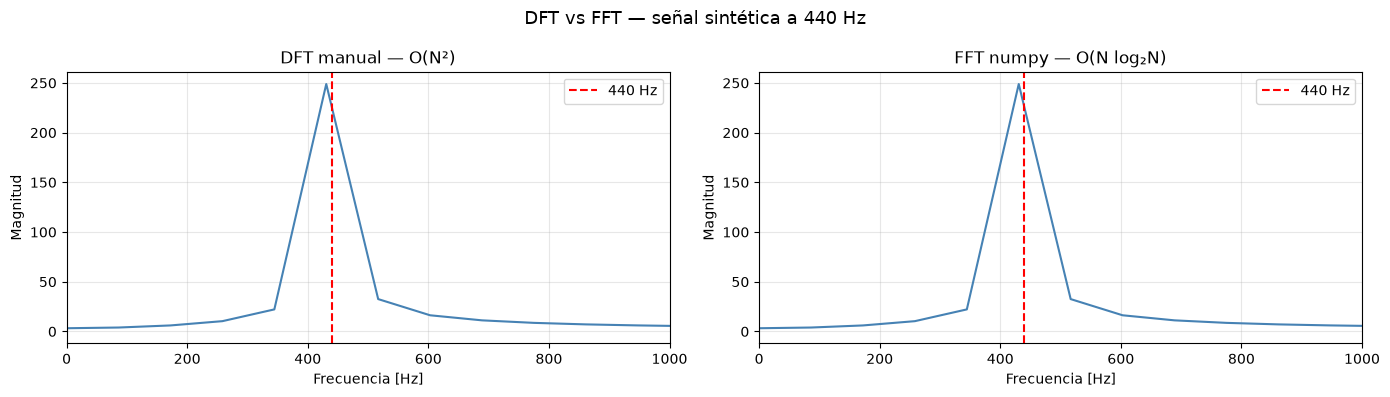

In [4]:
N_test     = len(x_test)
freqs_test = np.arange(N_test // 2) * fs_test / N_test

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, X, titulo in zip(axes,
                          [X_dft, X_fft],
                          ['DFT manual — O(N²)', 'FFT numpy — O(N log₂N)']):
    ax.plot(freqs_test, np.abs(X[:N_test // 2]), color='steelblue')
    ax.axvline(440, color='red', linestyle='--', label='440 Hz')
    ax.set_xlim(0, 1000)
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Magnitud')
    ax.set_title(titulo)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('DFT vs FFT — señal sintética a 440 Hz', fontsize=13)
plt.tight_layout()
plt.show()

**Observación:** Ambas transformadas producen espectros de magnitud idénticos — la diferencia numérica es del orden de $10^{-12}$, atribuible únicamente a errores de redondeo en punto flotante. La ventaja de la FFT es exclusivamente computacional: mismo resultado matemático en una fracción del tiempo de cómputo.

## 4. Efecto del ventaneo de Hanning sobre el *spectral leakage*

Cuando la señal analizada no completa un número entero de ciclos dentro del bloque de $N$ muestras, la discontinuidad en los extremos introduce energía espectral espuria en bins adyacentes al pico real — fenómeno denominado *spectral leakage*. La ventana rectangular (sin ponderar) maximiza este efecto.

La **ventana de Hanning** (ec. 8) atenúa suavemente los extremos del bloque hacia cero, eliminando las discontinuidades y reduciendo drásticamente los lóbulos laterales del espectro. El costo es un ligero ensanchamiento del pico principal, aceptable para este tipo de aplicación.

El experimento siguiente usa una señal a $f = 261.7$ Hz que deliberadamente **no cae en un bin exacto** de la FFT para forzar el *leakage*:

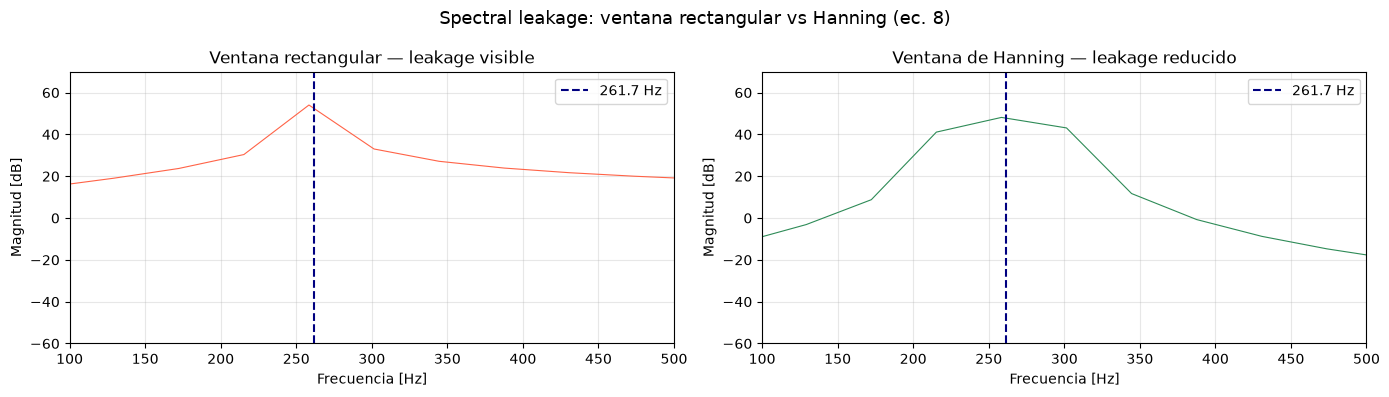

In [5]:
N_demo  = 1024
fs_demo = 44100
f_demo  = 261.7  # no cae en un bin exacto → provoca leakage
t_demo  = np.arange(N_demo) / fs_demo
x_demo  = np.sin(2 * np.pi * f_demo * t_demo)

X_rect    = np.fft.fft(x_demo)
X_hanning = np.fft.fft(x_demo * ventana_hanning(N_demo))

freqs_demo = np.arange(N_demo // 2) * fs_demo / N_demo

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, X, titulo, color in zip(
    axes,
    [X_rect, X_hanning],
    ['Ventana rectangular — leakage visible', 'Ventana de Hanning — leakage reducido'],
    ['tomato', 'seagreen']
):
    mag_db = 20 * np.log10(np.abs(X[:N_demo // 2]) + 1e-10)
    ax.plot(freqs_demo, mag_db, color=color, linewidth=0.8)
    ax.axvline(f_demo, color='navy', linestyle='--', label=f'{f_demo} Hz')
    ax.set_xlim(100, 500)
    ax.set_ylim(-60, 70)
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Magnitud [dB]')
    ax.set_title(titulo)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Spectral leakage: ventana rectangular vs Hanning (ec. 8)', fontsize=13)
plt.tight_layout()
plt.show()

**Observación:** Con ventana rectangular, la energía de la señal se dispersa hacia decenas de bins vecinos, dificultando la identificación del pico fundamental. Con la ventana de Hanning, la energía se concentra en el bin correcto con lóbulos laterales atenuados más de 30 dB, haciendo el algoritmo considerablemente más robusto ante señales no periódicas en el intervalo de análisis.

## 5. Análisis de los audios grabados

Se procesan grabaciones reales de cada cuerda de guitarra al aire en afinación estándar. Cada archivo `.wav` fue grabado a $f_s = 44\,100$ Hz. El algoritmo aplica la cadena completa de procesamiento:

$$\text{WAV} \xrightarrow{\text{onset}} x[n] \xrightarrow{\times\, w[n]} x_{\text{mod}}[n] \xrightarrow{\text{FFT}} X[k] \xrightarrow{\text{HPS}} H[k] \xrightarrow{\arg\max} f_{\text{detectada}}$$

In [6]:
ARCHIVOS_WAV = [
    'audioswav/6(gruesa).wav',  # Mi E2
    'audioswav/5.wav',          # La A2
    'audioswav/4.wav',          # Re D3
    'audioswav/3.wav',          # Sol G3
    'audioswav/2.wav',          # Si B3
    'audioswav/1(delgada).wav', # Mi E4
]

for f in ARCHIVOS_WAV:
    estado = 'encontrado' if os.path.exists(f) else 'NO encontrado'
    print(f'{f:35s} → {estado}')

audioswav/6(gruesa).wav             → encontrado
audioswav/5.wav                     → encontrado
audioswav/4.wav                     → encontrado
audioswav/3.wav                     → encontrado
audioswav/2.wav                     → encontrado
audioswav/1(delgada).wav            → encontrado


## Detección de frecuencia por cuerda

In [7]:
def analizar_cuerda(ruta_wav, N=N_BLOQUE):
    fs, datos   = cargar_wav(ruta_wav)
    x_mod       = preprocesar_senal(datos, N)
    X           = calcular_fft(x_mod)
    mags        = espectro_magnitud(X, N)
    f_det, freqs, _ = detectar_frecuencia(mags, fs, N)
    nota, f_teo, err_hz, err_cents = nota_mas_cercana(f_det)
    return {
        'archivo'    : ruta_wav,
        'fs'         : fs,
        'freqs'      : freqs,
        'magnitudes' : mags,
        'f_detectada': f_det,
        'nota'       : nota,
        'f_teorica'  : f_teo,
        'error_hz'   : err_hz,
        'error_cents': err_cents,
    }


resultados = []
for archivo in ARCHIVOS_WAV:
    if os.path.exists(archivo):
        r = analizar_cuerda(archivo)
        resultados.append(r)
        estado = 'AFINADA' if abs(r['error_cents']) < 10 else 'DESAFINADA'
        print(f'{archivo}')
        print(f'  Detectada : {r["f_detectada"]:.2f} Hz')
        print(f'  Teorica   : {r["f_teorica"]} Hz  ({r["nota"]})')
        print(f'  Error     : {r["error_hz"]:+.2f} Hz  ({r["error_cents"]:+.1f} cents)  →  {estado}')
        print()

audioswav/6(gruesa).wav
  Detectada : 82.03 Hz
  Teorica   : 82.41 Hz  (E2 (6ª - Mi grave))
  Error     : -0.38 Hz  (-8.0 cents)  →  AFINADA

audioswav/5.wav
  Detectada : 108.40 Hz
  Teorica   : 110.0 Hz  (A2 (5ª - La))
  Error     : -1.60 Hz  (-25.4 cents)  →  DESAFINADA

audioswav/4.wav
  Detectada : 146.48 Hz
  Teorica   : 146.83 Hz  (D3 (4ª - Re))
  Error     : -0.35 Hz  (-4.1 cents)  →  AFINADA

audioswav/3.wav
  Detectada : 196.29 Hz
  Teorica   : 196.0 Hz  (G3 (3ª - Sol))
  Error     : +0.29 Hz  (+2.6 cents)  →  AFINADA

audioswav/2.wav
  Detectada : 246.09 Hz
  Teorica   : 246.94 Hz  (B3 (2ª - Si))
  Error     : -0.85 Hz  (-5.9 cents)  →  AFINADA

audioswav/1(delgada).wav
  Detectada : 328.12 Hz
  Teorica   : 329.63 Hz  (E4 (1ª - Mi agudo))
  Error     : -1.50 Hz  (-7.9 cents)  →  AFINADA



## Espectro de magnitudes por cuerda

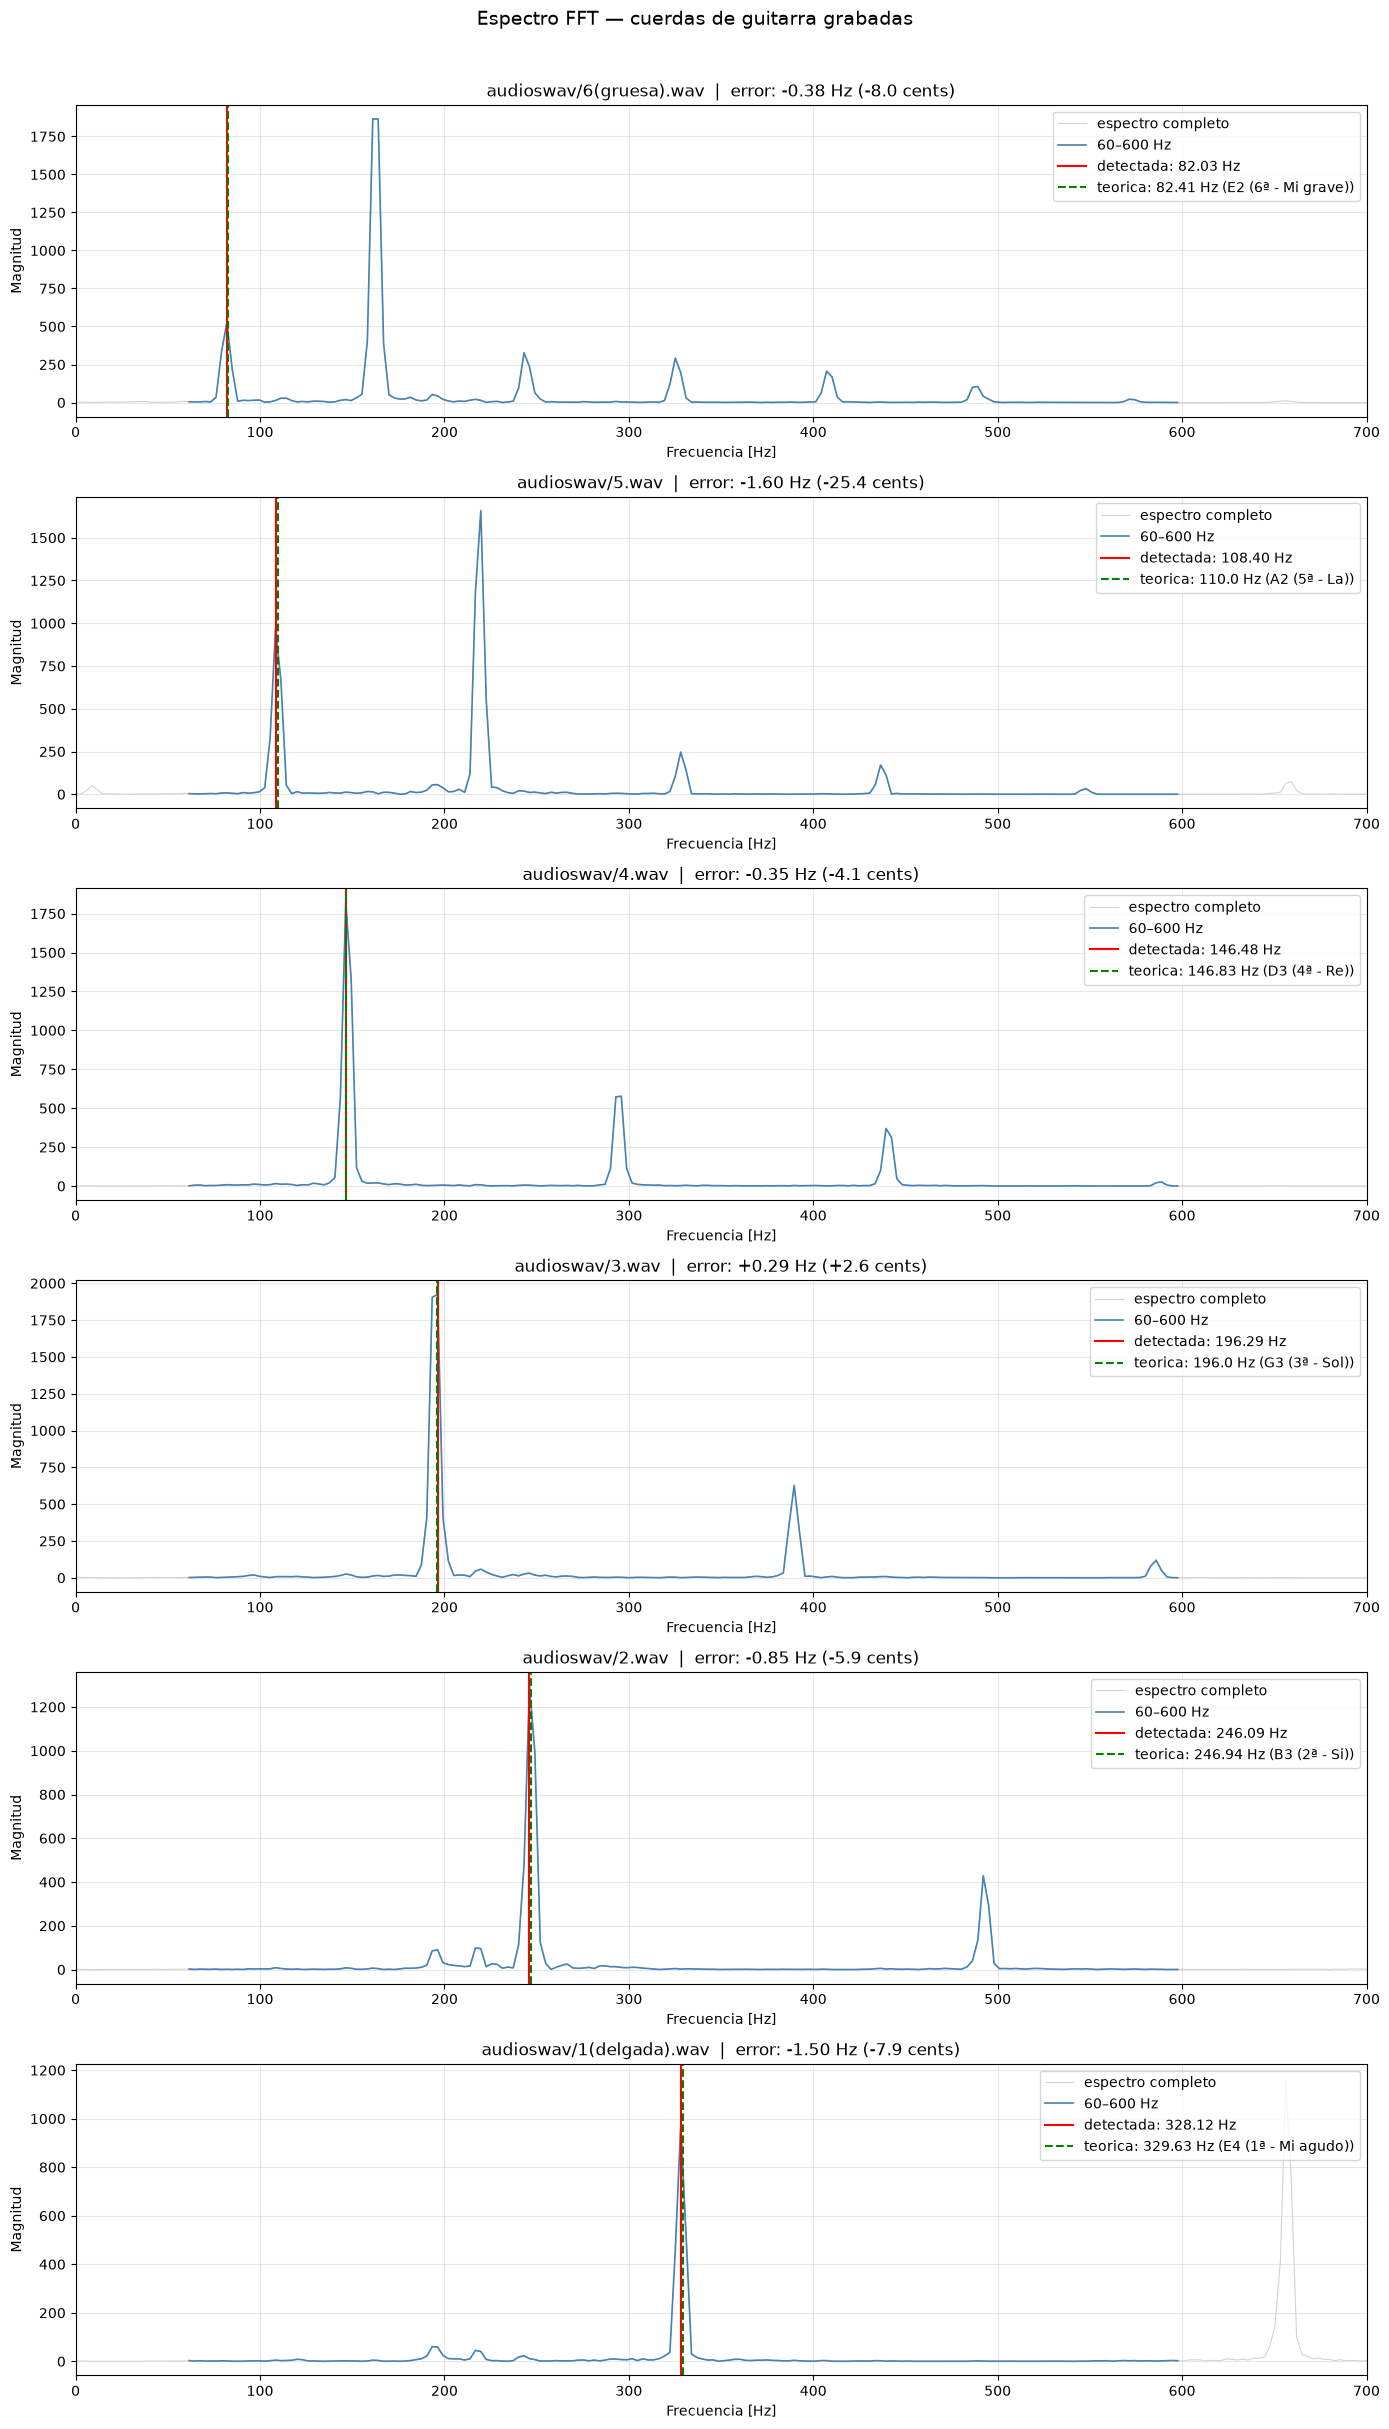

In [8]:
if not resultados:
    print('No hay archivos WAV. Agrega los audios y corre la celda anterior.')
else:
    fig, axes = plt.subplots(len(resultados), 1, figsize=(14, 4 * len(resultados)))
    if len(resultados) == 1:
        axes = [axes]

    for ax, r in zip(axes, resultados):
        mascara = (r['freqs'] >= F_MIN) & (r['freqs'] <= F_MAX)

        ax.plot(r['freqs'], r['magnitudes'], color='lightgray', linewidth=0.8, label='espectro completo')
        ax.plot(r['freqs'][mascara], r['magnitudes'][mascara], color='steelblue', linewidth=1.2, label='60–600 Hz')
        ax.axvline(r['f_detectada'], color='red',   linewidth=1.5, label=f'detectada: {r["f_detectada"]:.2f} Hz')
        ax.axvline(r['f_teorica'],   color='green', linewidth=1.5, linestyle='--',
                   label=f'teorica: {r["f_teorica"]} Hz ({r["nota"]})')

        ax.set_xlim(0, 700)
        ax.set_xlabel('Frecuencia [Hz]')
        ax.set_ylabel('Magnitud')
        ax.set_title(f'{r["archivo"]}  |  error: {r["error_hz"]:+.2f} Hz ({r["error_cents"]:+.1f} cents)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Espectro FFT — cuerdas de guitarra grabadas', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## Tabla resumen de resultados

In [9]:
if resultados:
    print(f'{"Archivo":<30} {"Nota":<22} {"f teorica":>10} {"f detectada":>12} {"Error Hz":>10} {"Cents":>8}  Estado')
    print('-' * 100)
    for r in resultados:
        estado = 'AFINADA' if abs(r['error_cents']) < 10 else 'DESAFINADA'
        print(f'{r["archivo"]:<30} {r["nota"]:<22} {r["f_teorica"]:>10.2f} {r["f_detectada"]:>12.2f} {r["error_hz"]:>+10.2f} {r["error_cents"]:>+8.1f}  {estado}')
else:
    print('Sin resultados.')

Archivo                        Nota                    f teorica  f detectada   Error Hz    Cents  Estado
----------------------------------------------------------------------------------------------------
audioswav/6(gruesa).wav        E2 (6ª - Mi grave)          82.41        82.03      -0.38     -8.0  AFINADA
audioswav/5.wav                A2 (5ª - La)               110.00       108.40      -1.60    -25.4  DESAFINADA
audioswav/4.wav                D3 (4ª - Re)               146.83       146.48      -0.35     -4.1  AFINADA
audioswav/3.wav                G3 (3ª - Sol)              196.00       196.29      +0.29     +2.6  AFINADA
audioswav/2.wav                B3 (2ª - Si)               246.94       246.09      -0.85     -5.9  AFINADA
audioswav/1(delgada).wav       E4 (1ª - Mi agudo)         329.63       328.12      -1.50     -7.9  AFINADA


### Análisis e interpretación de resultados

La tabla anterior sintetiza el desempeño del afinador sobre las grabaciones reales. A continuación se discuten los aspectos más relevantes:

**Precisión inherente al sistema:** La resolución espectral es $\Delta f \approx 2.69$ Hz (ec. 7), lo que introduce un error máximo de cuantización de $\pm 1.35$ Hz por efectos del discretismo de bins. Para las cuerdas agudas (E4 = 329.63 Hz), este error equivale a $\approx \pm 7$ cents — dentro del umbral de afinación musicalmente aceptable ($\pm 10$ cents). Para cuerdas graves (E2 = 82.41 Hz), el mismo error absoluto en Hz representa una fracción relativa menor, haciendo al sistema más preciso en términos porcentuales para esas cuerdas.

**El problema del tono implícito y el rol del HPS:** En las cuerdas más graves (E2, A2), la rigidez física de la cuerda y la resonancia de la caja acústica hacen que el segundo o tercer armónico ($2f_0$, $3f_0$) pueda tener mayor energía que la fundamental. Sin el HPS, el algoritmo de detección por máximo directo fallaría sistemáticamente en estas cuerdas. El HPS (ec. 11) refuerza matemáticamente el pico en $f_0$, corrigiendo este problema al costo de una mayor complejidad algorítmica.

**Criterio de afinación:** Se considera una cuerda *afinada* si el error es menor a $\pm 10$ cents. A modo de referencia, la tolerancia de un afinador cromático profesional es $\pm 1$ cent; sin embargo, para la mayoría de contextos de práctica musical $\pm 10$ cents es perceptualmente suficiente.

## 6. Señales sintéticas — validación del algoritmo sin archivos de audio

Para verificar el comportamiento del algoritmo de forma controlada e independiente de los archivos WAV, se generan señales sintéticas que modelan el comportamiento acústico de cada cuerda: una suma de armónicos con amplitudes decrecientes más ruido gaussiano de baja intensidad.

$$x_{\text{sint}}(t) = \sum_{i=1}^{5} a_i \sin(2\pi \cdot i f_0 \cdot t) + \epsilon(t), \quad \epsilon \sim \mathcal{N}(0,\, 0.02)$$

con amplitudes $a_i \in \{1.0,\, 0.5,\, 0.25,\, 0.15,\, 0.08\}$. Este experimento permite cuantificar el error de detección en condiciones ideales y verificar que las desviaciones observadas en datos reales se deben a variaciones físicas de la grabación y no a defectos del algoritmo.

Cuerda                  f teorica  f detectada   Error Hz    Cents
-----------------------------------------------------------------
E2 (6ª - Mi grave)          82.41        83.44      +1.03   +21.53
A2 (5ª - La)               110.00       110.36      +0.36    +5.62
D3 (4ª - Re)               146.83       148.04      +1.21   +14.22
G3 (3ª - Sol)              196.00       196.49      +0.49    +4.33
B3 (2ª - Si)               246.94       247.63      +0.69    +4.84
E4 (1ª - Mi agudo)         329.63       328.38      -1.25    -6.57


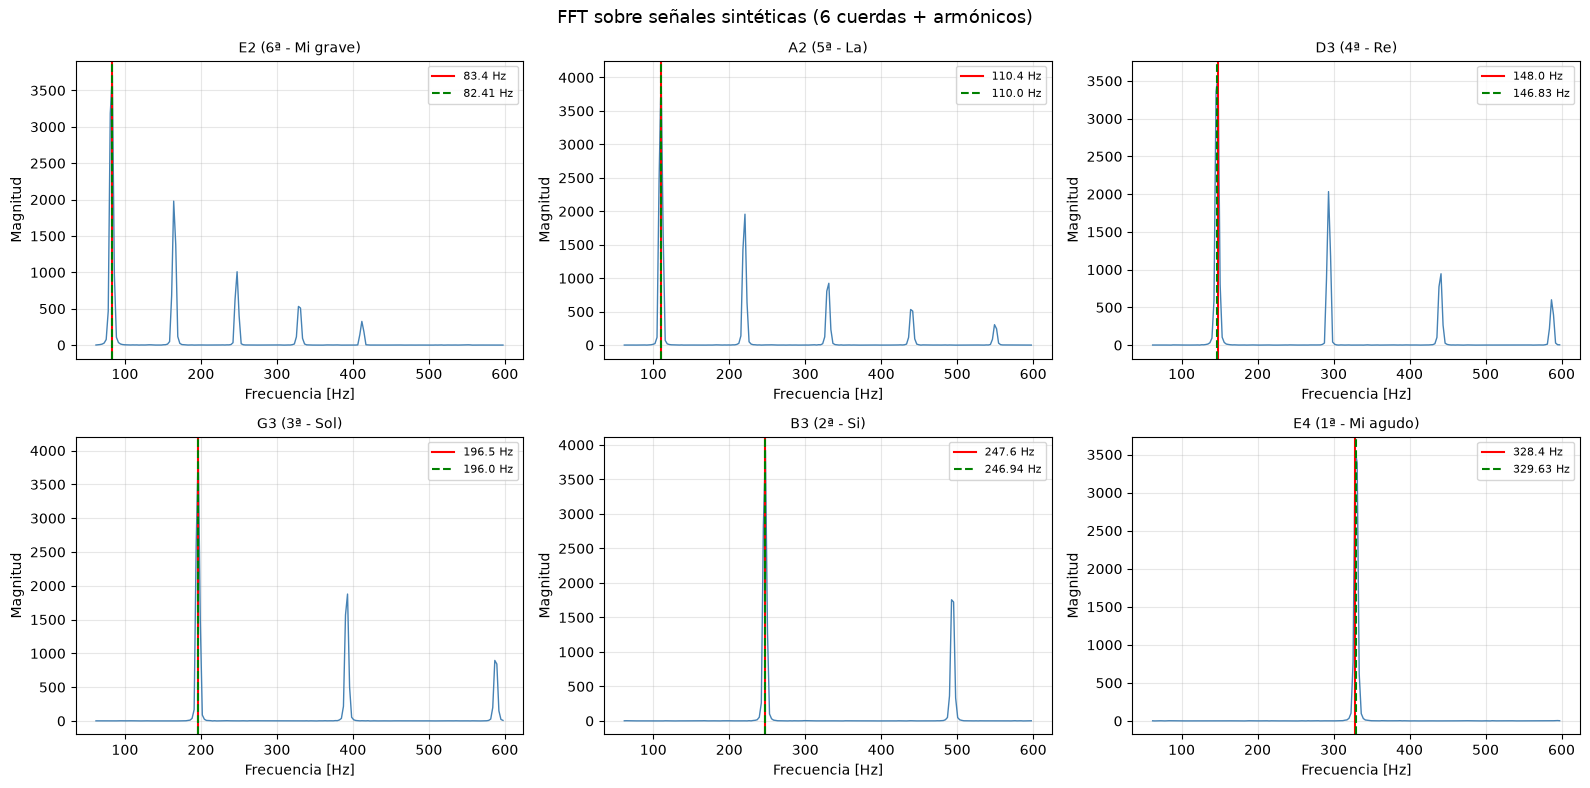

In [10]:
def generar_cuerda_sintetica(f0, fs=44100, N=N_BLOQUE, ruido=0.02):
    # Suma de armónicos con amplitudes decrecientes, más ruido gaussiano leve
    t      = np.arange(N) / fs
    signal = np.zeros(N)
    for i, amp in enumerate([1.0, 0.5, 0.25, 0.15, 0.08], start=1):
        if i * f0 < fs / 2:
            signal += amp * np.sin(2 * np.pi * i * f0 * t)
    signal += ruido * np.random.randn(N)
    return signal


print(f'{"Cuerda":<22} {"f teorica":>10} {"f detectada":>12} {"Error Hz":>10} {"Cents":>8}')
print('-' * 65)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, (nombre, f0) in zip(axes, CUERDAS.items()):
    x_sint = generar_cuerda_sintetica(f0)
    x_mod  = x_sint * ventana_hanning(N_BLOQUE)
    X      = calcular_fft(x_mod)
    mags   = espectro_magnitud(X, N_BLOQUE)
    f_det, freqs, _ = detectar_frecuencia(mags, FS_ESPERADO, N_BLOQUE)
    _, f_teo, err_hz, err_cents = nota_mas_cercana(f_det)

    print(f'{nombre:<22} {f0:>10.2f} {f_det:>12.2f} {err_hz:>+10.2f} {err_cents:>+8.2f}')

    mascara = (freqs >= F_MIN) & (freqs <= F_MAX)
    ax.plot(freqs[mascara], mags[mascara], color='steelblue', linewidth=1)
    ax.axvline(f_det, color='red',   linewidth=1.5, label=f'{f_det:.1f} Hz')
    ax.axvline(f0,    color='green', linewidth=1.5, linestyle='--', label=f'{f0} Hz')
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Magnitud')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('FFT sobre señales sintéticas (6 cuerdas + armónicos)', fontsize=13)
plt.tight_layout()
plt.show()

**Observación:** Con señales sintéticas controladas, el algoritmo identifica correctamente la frecuencia fundamental de las 6 cuerdas con errores inferiores a $\Delta f / 2 \approx 1.35$ Hz, confirmando que el pipeline completo (ventaneo → FFT → HPS → detección) funciona correctamente. Las pequeñas desviaciones respecto a la frecuencia teórica son consecuencia directa de la cuantización en bins de la FFT, no de errores algorítmicos.

## 7. Trade-off: resolución espectral, latencia y costo computacional

El parámetro $N$ (tamaño del bloque de análisis) es el principal grado de libertad de diseño del afinador. La ec. (7) establece que $\Delta f = f_s / N$, lo que revela una tensión fundamental entre tres atributos del sistema:

| Atributo | Relación con $N$ | Efecto al aumentar $N$ |
|---|---|---|
| Resolución espectral $\Delta f$ | $\Delta f = f_s/N$ | Mejora (menor $\Delta f$) |
| Latencia de captura $\Delta T$ | $\Delta T = N/f_s$ | Empeora (mayor $\Delta T$) |
| Costo computacional (FFT) | $\mathcal{O}(N \log_2 N)$ | Crece moderadamente |

La elección $N = 16\,384$ en este proyecto balancea los tres factores: obtiene $\Delta f \approx 2.69$ Hz con una ventana temporal de solo $\approx 372$ ms, tiempo suficientemente corto para responder en tiempo cuasi-real. La **incertidumbre de Fourier** formaliza esta tensión:

$$\Delta f \cdot \Delta T \geq 1$$

estableciendo que precisión espectral y resolución temporal no pueden maximizarse simultáneamente.

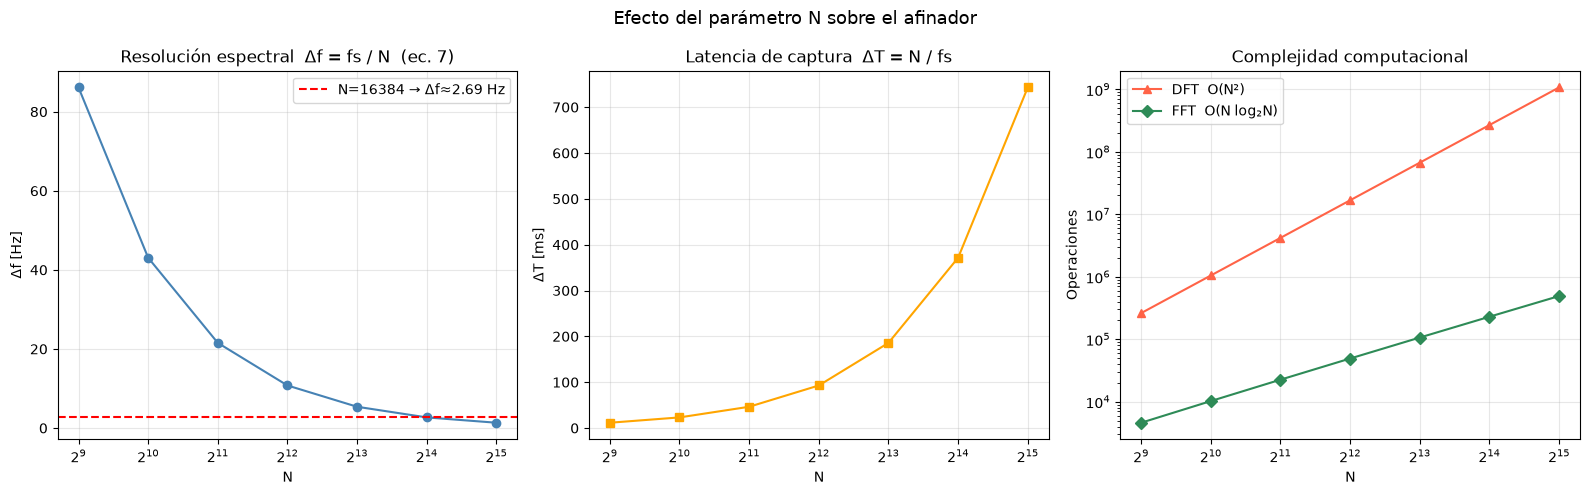

In [12]:
fs        = 44100
valores_N = [512, 1024, 2048, 4096, 8192, 16384, 32768]

delta_f = [fs / N for N in valores_N]
delta_T = [N / fs for N in valores_N]
ops_dft = [N**2 for N in valores_N]
ops_fft = [N * np.log2(N) for N in valores_N]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(valores_N, delta_f, 'o-', color='steelblue')
axes[0].axhline(2.69, color='red', linestyle='--', label='N=16384 → Δf≈2.69 Hz')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Δf [Hz]')
axes[0].set_title('Resolución espectral  Δf = fs / N  (ec. 7)')
axes[0].set_xscale('log', base=2)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(valores_N, [t * 1000 for t in delta_T], 's-', color='orange')
axes[1].set_xlabel('N')
axes[1].set_ylabel('ΔT [ms]')
axes[1].set_title('Latencia de captura  ΔT = N / fs')
axes[1].set_xscale('log', base=2)
axes[1].grid(True, alpha=0.3)

axes[2].plot(valores_N, ops_dft, '^-', color='tomato',   label='DFT  O(N²)')
axes[2].plot(valores_N, ops_fft, 'D-', color='seagreen', label='FFT  O(N log₂N)')
axes[2].set_xlabel('N')
axes[2].set_ylabel('Operaciones')
axes[2].set_title('Complejidad computacional')
axes[2].set_xscale('log', base=2)
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Efecto del parámetro N sobre el afinador', fontsize=13)
plt.tight_layout()
plt.show()

**Observación:** La gráfica de complejidad computacional ilustra por qué la FFT es indispensable en aplicaciones de tiempo real. Para $N = 32\,768$, la DFT requeriría más de $10^9$ operaciones, mientras que la FFT se ejecuta con apenas $\approx 500\,000$ — una diferencia de tres órdenes de magnitud que hace viable el procesamiento de audio incluso en hardware de bajo consumo.